In [2]:
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd
import numpy as np
import time
import os
import pickle
import matplotlib.pyplot as plt
import json
from statsmodels.tsa.stattools import coint 
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Pull and store data from python-binance

In [3]:
client = bnb_client()

In [4]:
exclude_symbols = [
    # Original stablecoins/pegged
    'USDCUSDT', 'USD1USDT', 'FDUSDUSDT', 'RLUSDUSDT', 'EURUSDT', 'EURIUSDT', 'PAXGUSDT', 'XAUTUSDT',
    'XUSDUSDT', 'UUSDT',
    # New stablecoins found in the 500-coin pull
    'USDEUSDT', 'USDSUSDT', 'USDPUSDT', 'TUSDUSDT', 'BFUSDUSDT', 'FRAXUSDT',
    # Wrapped/staked assets
    'WBTCUSDT', 'BNSOLUSDT', 'WBETHUSDT',
    # Tokenized equities (original set)
    'SPYBUSDT', 'QQQBUSDT', 'MSTRBUSDT', 'SOXLBUSDT', 'SPCXBUSDT', 'SNDKBUSDT', 'SNXXBUSDT', 'SKHYBUSDT',
    # Tokenized equities (new, from the 500-coin pull)
    'NVDABUSDT', 'TSLABUSDT', 'GOOGLBUSDT', 'AAPLBUSDT', 'AMZNBUSDT', 'MRVLBUSDT', 'INTCBUSDT', 'COINBUSDT',
    'NBISBUSDT', 'SOXSBUSDT', 'CBRSBUSDT', 'HOODBUSDT', 'AVGOBUSDT', 'ORCLBUSDT', 'PLTRBUSDT', 'FLNCBUSDT',
    'MSFTBUSDT', 'TQQQBUSDT', 'ARMBUSDT', 'INTWBUSDT', 'QCOMBUSDT', 'GLWBUSDT', 'TSMBUSDT', 'EWYBUSDT',
    'CRDOBUSDT', 'NOKBUSDT', 'SMHBUSDT', 'DELLBUSDT', 'IBMBUSDT', 'QNTBUSDT', 'AMATBUSDT', 'AAOIBUSDT',
    'WDCBUSDT', 'AMDBUSDT', 'RKLBBUSDT', 'ASTSBUSDT', 'SMCIBUSDT', 'NFLXBUSDT', 'BEBUSDT', 'BABABUSDT',
    'PYPLBUSDT', 'MVLLBUSDT', 'ALABBUSDT', 'AXTIBUSDT', 'LITEBUSDT', 'GMEBUSDT', 'IRENBUSDT', 'ASMLBUSDT',
    'CRWVBUSDT', 'DJTBUSDT', 'METABUSDT',
    # Unusual/mystery ticker
    '币安人生USDT'
]

In [5]:
# tickers_24h = client.get_ticker()
# vol_df = pd.DataFrame(tickers_24h)
# vol_df['quoteVolume'] = vol_df['quoteVolume'].astype(float)

# usdt_tickers = [
#     s['symbol'] for s in client.get_exchange_info()['symbols']
#     if s['status'] == 'TRADING'
#     and s['quoteAsset'] == 'USDT'
#     and s['isSpotTradingAllowed']
# ]

# vol_df = vol_df[vol_df['symbol'].isin(usdt_tickers)]
# vol_df = vol_df.sort_values('quoteVolume', ascending=False)

# top_symbols_500 = vol_df.head(500)['symbol'].tolist()
# top_symbols_500 = [s for s in top_symbols_500 if s not in exclude_symbols]

# print(len(top_symbols_500))

# with open("data/top_symbols_500.json", "w") as f:
#     json.dump(top_symbols_500, f)

In [6]:
# os.makedirs("data", exist_ok=True)
# cols = ["open_time","open","high","low","close","volume",
#         "close_time","quote_asset_volume","num_trades",
#         "taker_buy_base_vol","taker_buy_quote_vol","ignore"]

# for i, symbol in enumerate(top_symbols_500):
#     try:
#         klines = client.get_historical_klines(symbol, '1h', '2017-01-01')
#         df = pd.DataFrame(klines, columns=cols)
#         df['open_time'] = pd.to_datetime(df["open_time"], unit="ms")
#         df[["open", "high", "low", "close", "volume", "quote_asset_volume"]] = \
#         df[["open", "high", "low", "close", "volume", "quote_asset_volume"]].astype(float)
#         df.to_parquet(f"data/{symbol}.parquet")
#         print(f"[{i+1}/{len(top_symbols_500)}] {symbol} done — {len(df)} rows")
#         time.sleep(0.3)
#     except Exception as e:
#         print(f"[{i+1}/{len(top_symbols_500)}] Failed on {symbol}: {e}")

In [7]:
import glob

data = {}

with open("data/top_symbols_500.json", "r") as f:
    top_symbols_500 = json.load(f)

print(f"Loaded {len(top_symbols_500)} symbols from JSON")

for symbol in top_symbols_500:
    if symbol in exclude_symbols:
        continue
    df = pd.read_parquet(f"data/{symbol}.parquet")
    df = df.set_index('open_time')  # if not already indexed
    data[symbol] = df

print(f"Loaded {len(data)} symbols")

Loaded 465 symbols from JSON
Loaded 406 symbols


# Reversal/Momentum Analysis: Signal Detection, Portfolio Backtest & Transaction Cost Impact

In [8]:
#4h trying to find 4h patterns

timeframes = ['1h', '2h', '4h', '12h', '24h', '36h', '2D', '3D', '4D', '1W', '3W', '1ME', '6ME', '1YE']

past_returns = {}
future_returns = {}

ohlc_agg = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum',
        'quote_asset_volume': 'sum'
    }

for timeframe in timeframes:

    past_returns[timeframe] = {}
    future_returns[timeframe] = {}

    lookback = timeframe
    holding = timeframe

    for coin in data.keys():
        
        df = data[coin]
        resampled_df = df.resample(lookback).agg(ohlc_agg)  

        past_returns[timeframe][coin] = np.log(resampled_df['open']/resampled_df.shift()['open'])
        future_returns[timeframe][coin] = np.log(resampled_df.shift(-1)['open']/resampled_df['open'])

    

In [9]:
pooled_corr = {}
for timeframe in timeframes:
    all_past = pd.concat([past_returns[timeframe][key] for key in data.keys()])
    all_future = pd.concat([future_returns[timeframe][key] for key in data.keys()])
    pooled_corr[timeframe] = float(all_past.corr(all_future))

pooled_corr 

{'1h': -0.027499756410641805,
 '2h': -0.0362175794528282,
 '4h': -0.0353945091755816,
 '12h': -0.005871810494058683,
 '24h': -0.020741655580460212,
 '36h': -0.016704816697540373,
 '2D': -0.028665907720471034,
 '3D': -0.017850717275788852,
 '4D': -0.014446659853270002,
 '1W': -0.0034779159630274397,
 '3W': 0.018965560955056648,
 '1ME': 0.04990058534823216,
 '6ME': -0.010186050932202586,
 '1YE': -0.31575472920536024}

In [10]:
individual_corrs = {}
for timeframe in timeframes:
    individual_corrs[timeframe] = {}
    for key in data.keys():
        individual_corrs[timeframe][key] = past_returns[timeframe][key].corr(future_returns[timeframe][key]) 
    valid_corrs = [v for v in individual_corrs[timeframe].values() if not pd.isna(v)]
    positives = sum(1 for v in valid_corrs if v > 0)
    print(f"{timeframe}: {positives/len(valid_corrs)}")   

1h: 0.18472906403940886
2h: 0.15517241379310345
4h: 0.19704433497536947
12h: 0.3448275862068966
24h: 0.24630541871921183
36h: 0.312807881773399
2D: 0.2832512315270936
3D: 0.35467980295566504
4D: 0.43596059113300495
1W: 0.4753694581280788
3W: 0.48621553884711777
1ME: 0.5406091370558376


c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3028: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


6ME: 0.43452380952380953
1YE: 0.19111111111111112


In [11]:
test_timeframes = ['1h', '2h', '4h', '12h', '24h']

combined_past_rets = {}
combined_future_rets = {}

for tester in test_timeframes:
    combined_past_rets[tester] = pd.concat(past_returns[tester], axis=1)
    combined_future_rets[tester] = pd.concat(future_returns[tester], axis=1)

In [12]:
# print(combined_past_rets['4h'].shape)
# print(combined_past_rets['4h'].columns[:5])
# combined_past_rets['4h'].head()

In [13]:
# plt.plot(list(correlations.keys()), list(correlations.values()))
# plt.xlabel("Horizon")
# plt.ylabel("Correlation")
# plt.axhline(0, color='gray', linestyle = '--')
# plt.show()

[4h] positive ratio: 0.4191
[4h] avg turnover per period: 1.4629
[4h] final cumulative log return: -28.01


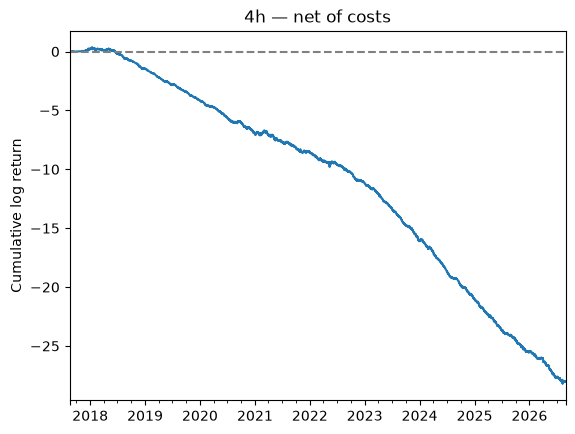

[12h] positive ratio: 0.4420
[12h] avg turnover per period: 1.4560
[12h] final cumulative log return: -14.16


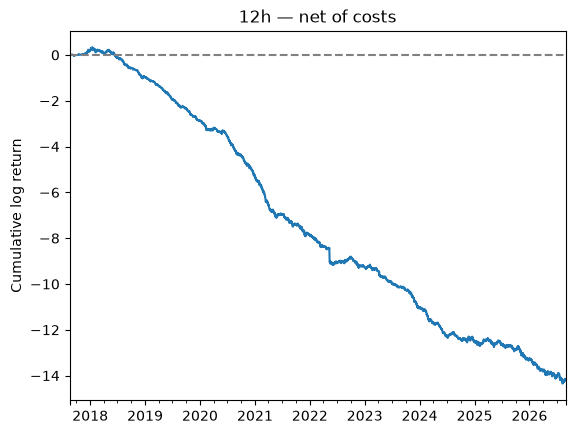

[24h] positive ratio: 0.4833
[24h] avg turnover per period: 1.4496
[24h] final cumulative log return: -4.32


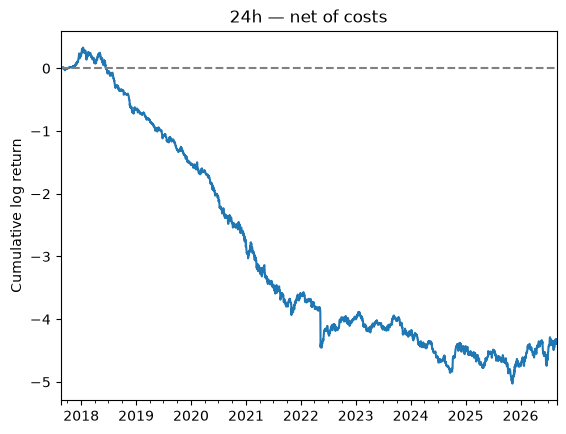

In [14]:
def run_backtest(timeframe, cost_rate=0.0020):
    portfolio_returns = {}
    previous_weights = pd.Series(0.0, index=data.keys())
    turnovers = []
    
    for date in combined_past_rets[timeframe].index:
        row = combined_past_rets[timeframe].loc[date].dropna()
        sorted_row = row.sort_values()
        losers = sorted_row.head(10)
        winners = sorted_row.tail(10)
        
        weights = pd.Series(0.0, index=data.keys())
        for coin in data.keys():
            if coin in losers:
                weights.loc[coin] = 0.05
            elif coin in winners:
                weights.loc[coin] = -0.05
        
        turnover = np.abs(weights - previous_weights).sum()
        turnovers.append(turnover)
        rebalancing_cost = turnover * cost_rate
        
        period_return = (weights * combined_future_rets[timeframe].loc[date]).sum()
        net_period_return = period_return - rebalancing_cost
        portfolio_returns[date] = net_period_return
        
        previous_weights = weights
    
    returns_series = pd.Series(portfolio_returns).dropna()
    print(f"[{timeframe}] positive ratio: {(returns_series > 0).mean():.4f}")
    print(f"[{timeframe}] avg turnover per period: {np.mean(turnovers):.4f}")
    print(f"[{timeframe}] final cumulative log return: {returns_series.cumsum().iloc[-1]:.2f}")
    
    returns_series.cumsum().plot(title=f"{timeframe} — net of costs")
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel("Cumulative log return")
    plt.show()
    
    return returns_series

returns_4h = run_backtest('4h')
returns_12h = run_backtest('12h')
returns_24h = run_backtest('24h')

-0.0014147132007450243
0.009545203211014729
0.8153180111153362


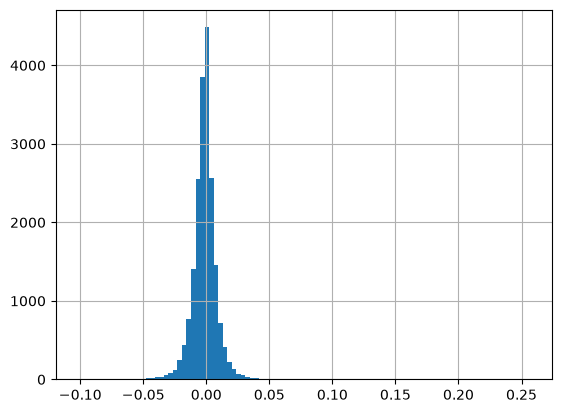

In [15]:
returns_4h.hist(bins=100)
print(returns_4h.mean())
print(returns_4h.std())
print(returns_4h.skew())

In [16]:
# cost_per_period = 0.0020  # 20bps, full turnover assumption
# portfolio_returns_net = portfolio_returns_series - cost_per_period
# portfolio_returns_net.cumsum().plot()

In [17]:
# n_obs = {tf: past_returns[tf].dropna().shape[0] for tf in timeframes}
# print(n_obs)

# Time-of-day / Weekday Effect: End of working day to next morning return relationship

In [18]:
afternoon_returns = {}
morning_returns = {}

afternoon_hours = [13, 14]
morning_hours = [9, 10]

for key in data.keys():
    coin_data = data[key]
    afternoon = coin_data[coin_data.index.hour.isin(afternoon_hours)]
    morning = coin_data[coin_data.index.hour.isin(morning_hours)]
    afternoon_daily = afternoon.groupby(afternoon.index.date).agg({'open':'first', 'close':'last'})
    afternoon_daily.index = pd.to_datetime(afternoon_daily.index)
    morning_daily = morning.groupby(morning.index.date).agg({'open':'first', 'close':'last'})
    morning_daily.index = pd.to_datetime(morning_daily.index)
    daysofweek = [0, 1, 2, 3, 4]
    afternoon_weekday = afternoon_daily[afternoon_daily.index.day_of_week.isin(daysofweek)]
    morning_weekday = morning_daily[morning_daily.index.day_of_week.isin(daysofweek)]
    morning_weekday['date'] = pd.to_datetime(morning_weekday.index.date)
    afternoon_weekday['target_date'] = pd.to_datetime(afternoon_weekday.index.date) + pd.offsets.BDay(1)
    merged = pd.merge(afternoon_weekday, morning_weekday, left_on='target_date', right_on='date', suffixes=('_afternoon', '_morning'))
    merged['afternoon_return'] = np.log(merged['close_afternoon']/merged['open_afternoon'])
    merged['morning_return'] = np.log(merged['close_morning']/merged['open_morning'])
    afternoon_returns[key] = merged['afternoon_return']
    morning_returns[key] = merged['morning_return']

all_afternoon = pd.concat(afternoon_returns.values())
all_morning = pd.concat(morning_returns.values())
pooled_afternoon_morning_corr = all_afternoon.corr(all_morning)
print(pooled_corr)
individual_corrs = {key: afternoon_returns[key].corr(morning_returns[key]) for key in data.keys()}
valid_corrs = [v for v in individual_corrs.values() if not pd.isna(v)]
positives = sum(1 for v in valid_corrs if v > 0)

print(f"{positives}/{len(valid_corrs)} = {positives/len(valid_corrs):.3f}")

{'1h': -0.027499756410641805, '2h': -0.0362175794528282, '4h': -0.0353945091755816, '12h': -0.005871810494058683, '24h': -0.020741655580460212, '36h': -0.016704816697540373, '2D': -0.028665907720471034, '3D': -0.017850717275788852, '4D': -0.014446659853270002, '1W': -0.0034779159630274397, '3W': 0.018965560955056648, '1ME': 0.04990058534823216, '6ME': -0.010186050932202586, '1YE': -0.31575472920536024}
249/406 = 0.613


# Using Trading Volume and Number of Trades to refine the Reversal / Momentum signal(s)

In [19]:
combined_past_rets = {}
combined_future_rets = {}

for timeframe in past_returns.keys():
    combined_past_rets[timeframe] = pd.concat(past_returns[timeframe], axis=1)
    combined_future_rets[timeframe] = pd.concat(future_returns[timeframe], axis=1)

combined_past_rets.keys()

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\3507419207.py:5: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_past_rets[timeframe] = pd.concat(past_returns[timeframe], axis=1)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\3507419207.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_future_rets[timeframe] = pd.concat(future_returns[timeframe], axis=1)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\3507419207.py:5: Pandas4Warning: Sorting by default when concatenatin

dict_keys(['1h', '2h', '4h', '12h', '24h', '36h', '2D', '3D', '4D', '1W', '3W', '1ME', '6ME', '1YE'])

In [20]:
def build_vol_zscore(timeframe, window):
    vol_zscores = {}
    for coin in data.keys():
        resampled_df = data[coin].resample(timeframe).agg(ohlc_agg)
        vol = resampled_df['quote_asset_volume']
        rolling_mean = vol.shift(1).rolling(window=window).mean()
        rolling_std = vol.shift(1).rolling(window=window).std()
        vol_zscores[coin] = (vol - rolling_mean) / rolling_std
    return pd.concat(vol_zscores, axis=1)

In [21]:
combined_vol_zscore = {}
combined_vol_zscore['4h'] = build_vol_zscore('4h', window=42)
combined_vol_zscore['12h'] = build_vol_zscore('12h', window=14)
combined_vol_zscore['24h'] = build_vol_zscore('24h', window=7)

for tf in combined_vol_zscore:
    print(tf, combined_vol_zscore[tf].shape)

4h (19797, 406)
12h (6600, 406)
24h (3300, 406)


In [22]:
def compute_pooled_corr(past_df, future_df):
    p = past_df.stack()
    f = future_df.stack()
    return p.corr(f), len(p)

In [23]:
def compare_vol_regimes(timeframe):
    quantiles = combined_vol_zscore[timeframe].stack().quantile([0.25, 0.75])
    low_cutoff = quantiles[0.25]
    high_cutoff = quantiles[0.75]
    
    high_vol_mask = combined_vol_zscore[timeframe] > high_cutoff
    low_vol_mask = combined_vol_zscore[timeframe] < low_cutoff
    
    past_high = combined_past_rets[timeframe][high_vol_mask]
    future_high = combined_future_rets[timeframe][high_vol_mask]
    
    past_low = combined_past_rets[timeframe][low_vol_mask]
    future_low = combined_future_rets[timeframe][low_vol_mask]
    
    corr_high, n_high = compute_pooled_corr(past_high, future_high)
    corr_low, n_low = compute_pooled_corr(past_low, future_low)
    
    print(f"[{timeframe}] High volume: corr = {corr_high:.4f}, n = {n_high}")
    print(f"[{timeframe}] Low volume: corr = {corr_low:.4f}, n = {n_low}")
    
    return low_cutoff, high_cutoff

In [24]:
low_cutoff_4h, high_cutoff_4h = compare_vol_regimes('4h')
low_cutoff_12h, high_cutoff_12h = compare_vol_regimes('12h')
low_cutoff_24h, high_cutoff_24h = compare_vol_regimes('24h')

[4h] High volume: corr = 0.0104, n = 8037582
[4h] Low volume: corr = -0.1991, n = 8037582
[12h] High volume: corr = 0.0605, n = 2679600
[12h] Low volume: corr = -0.1820, n = 2679600
[24h] High volume: corr = 0.0580, n = 1339800
[24h] Low volume: corr = -0.1644, n = 1339800


In [25]:
timeframe = '4h'

quantiles = combined_vol_zscore[timeframe].stack().quantile([0.25, 0.75])
low_cutoff = quantiles[0.25]
high_cutoff = quantiles[0.75]

high_vol_mask = combined_vol_zscore[timeframe] > high_cutoff
low_vol_mask = combined_vol_zscore[timeframe] < low_cutoff

past_high = combined_past_rets[timeframe][high_vol_mask]
future_high = combined_future_rets[timeframe][high_vol_mask]

past_low = combined_past_rets[timeframe][low_vol_mask]
future_low = combined_future_rets[timeframe][low_vol_mask]

print(past_high.shape, past_low.shape)

(19797, 406) (19797, 406)


In [26]:
def sign_agreement(past_df, future_df):
    individual_corrs = {}
    for coin in past_df.columns:
        p = past_df[coin]
        f = future_df[coin]
        individual_corrs[coin] = p.corr(f)  # pandas .corr() already drops NaN pairwise
    
    valid_corrs = [v for v in individual_corrs.values() if not pd.isna(v)]
    positives = sum(1 for v in valid_corrs if v > 0)
    return positives, len(valid_corrs), individual_corrs

pos_high, total_high, corrs_high = sign_agreement(past_high, future_high)
pos_low, total_low, corrs_low = sign_agreement(past_low, future_low)

print(f"High volume: {pos_high}/{total_high} positive = {pos_high/total_high:.3f}")
print(f"Low volume: {pos_low}/{total_low} positive = {pos_low/total_low:.3f}")

High volume: 258/406 positive = 0.635
Low volume: 3/406 positive = 0.007


In [27]:
def run_conditioned_backtest(timeframe, low_cutoff, n_candidates=30, cost_rate=0.0020, apply_costs=True):
    portfolio_returns = {}
    previous_weights = pd.Series(0.0, index=data.keys())
    turnovers = []
    
    for date in combined_past_rets[timeframe].index:
        row_return = combined_past_rets[timeframe].loc[date].dropna()
        row_vol = combined_vol_zscore[timeframe].loc[date]
        
        sorted_row = row_return.sort_values()
        candidates_losers = sorted_row.head(n_candidates)
        candidates_winners = sorted_row.tail(n_candidates)

        qualifying_losers = [c for c in candidates_losers.index if c in row_vol.index and row_vol[c] < low_cutoff]
        qualifying_winners = [c for c in candidates_winners.index if c in row_vol.index and row_vol[c] < low_cutoff]
        qualifying_coins = len(qualifying_losers) + len(qualifying_winners)
        
        weights = pd.Series(0.0, index=data.keys())
        if qualifying_coins > 0:
            for coin in qualifying_losers:
                weights[coin] = 1/qualifying_coins
            for coin in qualifying_winners:
                weights[coin] = -1/qualifying_coins
        
        turnover = np.abs(weights - previous_weights).sum()
        turnovers.append(turnover)
        rebalancing_cost = turnover * cost_rate if apply_costs else 0.0
        
        period_return = (weights * combined_future_rets[timeframe].loc[date]).sum()
        net_period_return = period_return - rebalancing_cost
        portfolio_returns[date] = net_period_return
        
        previous_weights = weights
    
    returns_series = pd.Series(portfolio_returns).dropna()
    label = "unconstrained" if not apply_costs else "net of costs"
    print(f"[{timeframe}] positive ratio: {(returns_series > 0).mean():.4f}")
    print(f"[{timeframe}] avg turnover per period: {np.mean(turnovers):.4f}")
    print(f"[{timeframe}] final cumulative log return: {returns_series.cumsum().iloc[-1]:.2f}")
    
    returns_series.cumsum().plot(title=f"{timeframe} — volume-conditioned reversal, {label}")
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel("Cumulative log return")
    plt.show()
    
    return returns_series

[12h] positive ratio: 0.4083
[12h] avg turnover per period: 1.4570
[12h] final cumulative log return: -11.35


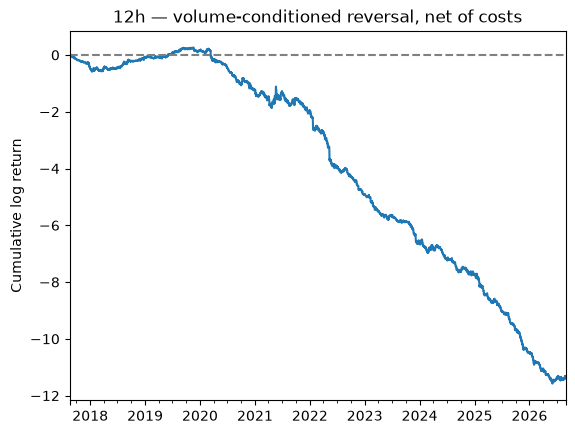

In [28]:
returns_12h_unconstrained = run_conditioned_backtest('12h', low_cutoff_12h)

In [29]:
def restricted_pooled_corr(timeframe, n_candidates=30):
    all_selected_past = []
    all_selected_future = []
    
    for date in combined_past_rets[timeframe].index:
        row_return = combined_past_rets[timeframe].loc[date].dropna()
        row_vol = combined_vol_zscore[timeframe].loc[date]
        row_future = combined_future_rets[timeframe].loc[date]
        
        sorted_row = row_return.sort_values()
        candidates = sorted_row.head(n_candidates).index.tolist() + sorted_row.tail(n_candidates).index.tolist()
        qualifying = [c for c in candidates if c in row_vol.index and row_vol[c] < low_cutoff]
        
        for c in qualifying:
            if not pd.isna(row_future.get(c, np.nan)):
                all_selected_past.append(row_return[c])
                all_selected_future.append(row_future[c])
    
    p = pd.Series(all_selected_past)
    f = pd.Series(all_selected_future)
    return p.corr(f), len(p)

corr_restricted, n_restricted = restricted_pooled_corr('4h')
print(f"Restricted (top/bottom-30 AND low-vol) correlation: {corr_restricted:.4f}, n={n_restricted}")
print(f"Original (all low-vol periods) correlation: -0.2059")

Restricted (top/bottom-30 AND low-vol) correlation: -0.2317, n=217084
Original (all low-vol periods) correlation: -0.2059


In [30]:
qualifying_counts = []
for date in combined_past_rets['4h'].index:
    row_return = combined_past_rets['4h'].loc[date].dropna()
    row_vol = combined_vol_zscore['4h'].loc[date]
    sorted_row = row_return.sort_values()
    candidates = sorted_row.head(30).index.tolist() + sorted_row.tail(30).index.tolist()
    qualifying = [c for c in candidates if c in row_vol.index and row_vol[c] < low_cutoff]
    qualifying_counts.append(len(qualifying))

print(pd.Series(qualifying_counts).describe())

count    19797.000000
mean        10.977421
std          9.984978
min          0.000000
25%          3.000000
50%          8.000000
75%         17.000000
max         56.000000
dtype: float64


In [31]:
combined_past_rets.keys()

dict_keys(['1h', '2h', '4h', '12h', '24h', '36h', '2D', '3D', '4D', '1W', '3W', '1ME', '6ME', '1YE'])

In [32]:
def run_conditioned_backtest_sticky(timeframe, strict_cutoff, loose_cutoff, n_candidates=70, cost_rate=0.0020, apply_costs=True):
    portfolio_returns = {}
    previous_weights = pd.Series(0.0, index=data.keys())
    turnovers = []
    
    for date in combined_past_rets[timeframe].index:
        row_return = combined_past_rets[timeframe].loc[date].dropna()
        row_vol = combined_vol_zscore[timeframe].loc[date]
        
        sorted_row = row_return.sort_values()
        candidates_losers = sorted_row.head(n_candidates).index.tolist()
        candidates_winners = sorted_row.tail(n_candidates).index.tolist()
        
        def qualifies(coin):
            currently_held = previous_weights.get(coin, 0.0) != 0.0
            vol_z = row_vol.get(coin, np.nan)
            if pd.isna(vol_z):
                return False
            cutoff = loose_cutoff if currently_held else strict_cutoff
            return vol_z < cutoff
        
        qualifying_losers = [c for c in candidates_losers if qualifies(c)]
        qualifying_winners = [c for c in candidates_winners if qualifies(c)]
        qualifying_coins = len(qualifying_losers) + len(qualifying_winners)
        
        weights = pd.Series(0.0, index=data.keys())
        if qualifying_coins > 0:
            for coin in qualifying_losers:
                weights[coin] = 1/qualifying_coins
            for coin in qualifying_winners:
                weights[coin] = -1/qualifying_coins
        
        turnover = np.abs(weights - previous_weights).sum()
        turnovers.append(turnover)
        rebalancing_cost = turnover * cost_rate if apply_costs else 0.0
        
        period_return = (weights * combined_future_rets[timeframe].loc[date]).sum()
        net_period_return = period_return - rebalancing_cost
        portfolio_returns[date] = net_period_return
        
        previous_weights = weights
    
    returns_series = pd.Series(portfolio_returns).dropna()
    label = "unconstrained" if not apply_costs else "net of costs"
    print(f"[{timeframe}] positive ratio: {(returns_series > 0).mean():.4f}")
    print(f"[{timeframe}] avg turnover per period: {np.mean(turnovers):.4f}")
    print(f"[{timeframe}] final cumulative log return: {returns_series.cumsum().iloc[-1]:.2f}")
    
    returns_series.cumsum().plot(title=f"{timeframe} — sticky volume-conditioned reversal, {label}")
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel("Cumulative log return")
    plt.show()
    
    return returns_series

[12h] positive ratio: 0.4032
[12h] avg turnover per period: 1.1941
[12h] final cumulative log return: -7.29


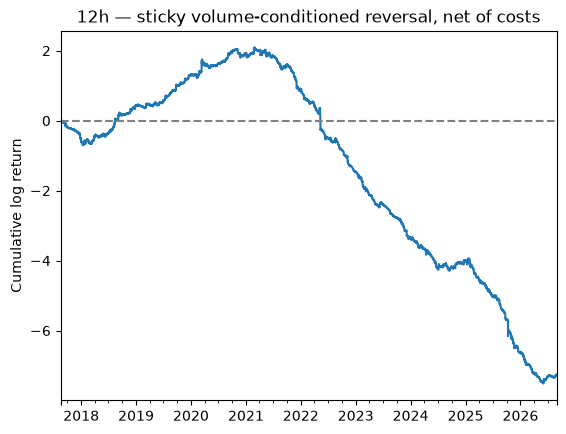

In [33]:
loose_cutoff_12h = combined_vol_zscore['12h'].stack().quantile(0.5)
returns_12h_sticky = run_conditioned_backtest_sticky('12h', low_cutoff_12h, loose_cutoff_12h)

In [34]:
# what fraction of the universe is actually excluded from candidacy at N=70?
sample_row = combined_past_rets['12h'].iloc[100].dropna()
print(f"Total coins with valid return data: {len(sample_row)}")
print(f"Candidates at N=70 (top+bottom): {min(70, len(sample_row))*2}")

Total coins with valid return data: 2
Candidates at N=70 (top+bottom): 4


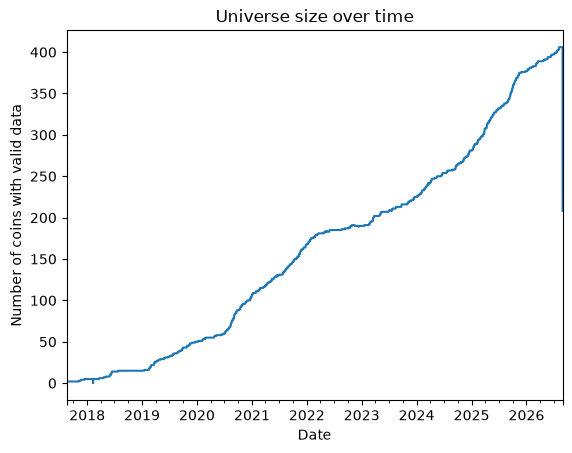

count    6600.000000
mean      164.016667
std       121.989817
min         0.000000
25%        48.000000
50%       176.500000
75%       250.000000
max       406.000000
dtype: float64


In [35]:
coin_counts = combined_past_rets['12h'].notna().sum(axis=1)
coin_counts.plot()
plt.ylabel("Number of coins with valid data")
plt.xlabel("Date")
plt.title("Universe size over time")
plt.show()

print(coin_counts.describe())

In [36]:
cutoff_date = coin_counts[coin_counts >= 90].index[0]
print(cutoff_date)

2020-10-14 12:00:00


In [37]:
combined_past_rets_trimmed = {}
combined_future_rets_trimmed = {}
combined_vol_zscore_trimmed = {}

for tf in ['4h', '12h', '24h']:
    combined_past_rets_trimmed[tf] = combined_past_rets[tf].loc[cutoff_date:]
    combined_future_rets_trimmed[tf] = combined_future_rets[tf].loc[cutoff_date:]
    combined_vol_zscore_trimmed[tf] = combined_vol_zscore[tf].loc[cutoff_date:]

print(combined_past_rets_trimmed['12h'].shape)

(4291, 406)


In [38]:
_orig_past = combined_past_rets
_orig_future = combined_future_rets
_orig_vol = combined_vol_zscore

combined_past_rets = combined_past_rets_trimmed
combined_future_rets = combined_future_rets_trimmed
combined_vol_zscore = combined_vol_zscore_trimmed

low_cutoff_12h_trimmed = combined_vol_zscore['12h'].stack().quantile(0.25)
print(low_cutoff_12h_trimmed)

-0.7399589882268018


[12h] positive ratio: 0.4353
[12h] avg turnover per period: 1.8049
[12h] final cumulative log return: -10.42


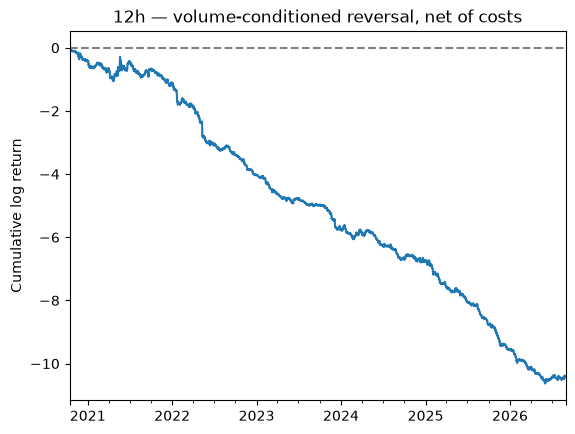

In [39]:
returns_12h_n30_trimmed = run_conditioned_backtest('12h', low_cutoff_12h_trimmed, n_candidates=30)

[12h] positive ratio: 0.4123
[12h] avg turnover per period: 1.7850
[12h] final cumulative log return: -10.04


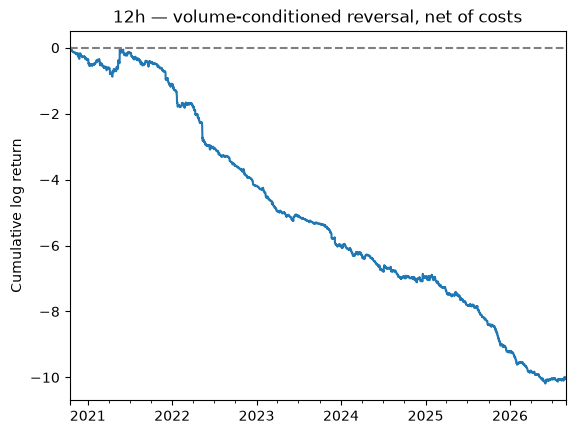

In [40]:
returns_12h_n50_trimmed = run_conditioned_backtest('12h', low_cutoff_12h_trimmed, n_candidates=50)

[12h] positive ratio: 0.3806
[12h] avg turnover per period: 1.7124
[12h] final cumulative log return: -9.76


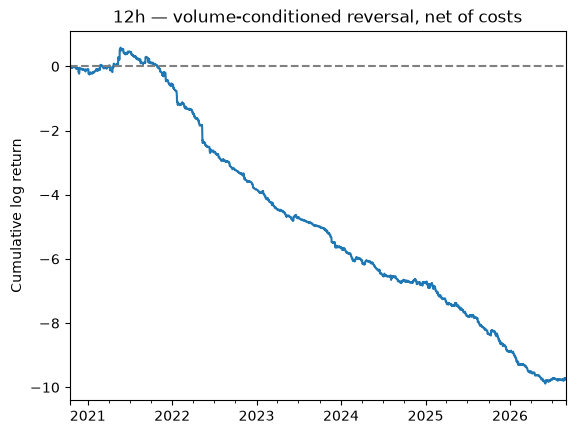

In [41]:
returns_12h_n70_trimmed = run_conditioned_backtest('12h', low_cutoff_12h_trimmed, n_candidates=70)

In [42]:
combined_past_rets = _orig_past
combined_future_rets = _orig_future
combined_vol_zscore = _orig_vol

print(combined_past_rets['12h'].shape)

(6600, 406)


# Pairs Trading - Mean-reversion

In [43]:
in_sample_end = '2023-06-01'      
out_of_sample_start = '2023-06-01' 

In [44]:
coin_corrs = combined_past_rets['24h'].loc[:in_sample_end].corr()
n = len(coin_corrs)
tri_rows, tri_cols = np.triu_indices(n, k=1)

In [45]:
paired_corrs_values = coin_corrs.values[tri_rows, tri_cols]
pair_coin_A = coin_corrs.columns[tri_rows]
pair_coin_B = coin_corrs.columns[tri_cols]
paired_corrs = pd.DataFrame({
    'coin_A' : pair_coin_A,
    'coin_B' : pair_coin_B,
    'correlation' : paired_corrs_values
})

In [46]:
shortlist = paired_corrs[paired_corrs['correlation'] > 0.7].sort_values('correlation', ascending=False)
print(len(shortlist))
shortlist.head(30)

419


,coin_A,coin_B,correlation
76816,GLMUSDT,CVCUSDT,0.911445
76847,GLMUSDT,POWRUSDT,0.889799
5678,PEPEUSDT,FLOKIUSDT,0.887271
2905,BNBUSDT,CAKEUSDT,0.884541
79397,MAGICUSDT,CVCUSDT,0.865780
66534,LSKUSDT,GLMUSDT,0.853773
641,ETHUSDT,GNOUSDT,0.853586
9830,LTCUSDT,BCHUSDT,0.851546
64726,LUNAUSDT,USTCUSDT,0.850047
751,ETHUSDT,ILVUSDT,0.849653


In [47]:
timeframe_pairs = '24h'
eg_results = []
min_in_sample_obs = 90  # need at least this many overlapping days to bother testing

for i in range(len(shortlist)):
    coin_A = shortlist.iloc[i]['coin_A']
    coin_B = shortlist.iloc[i]['coin_B']
    a_df = np.log(data[coin_A].resample(timeframe_pairs).agg(ohlc_agg)['close']).loc[:in_sample_end]
    b_df = np.log(data[coin_B].resample(timeframe_pairs).agg(ohlc_agg)['close']).loc[:in_sample_end]
    combined_pairs_df = pd.concat([a_df, b_df], axis=1, keys=['coin A', 'coin B']).dropna()
    
    if len(combined_pairs_df) < min_in_sample_obs:
        continue
    
    score, pvalue, crit_values = coint(combined_pairs_df['coin A'], combined_pairs_df['coin B'])
    n_obs = len(combined_pairs_df)
    eg_results.append({
        'coin_A' : coin_A,
        'coin_B' : coin_B,
        'pvalue' : pvalue,
        'score' : score,
        'n_obs' : n_obs
    })

print(f"Tested {len(eg_results)} / {len(shortlist)} pairs (rest skipped for insufficient in-sample history)")

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\4039938764.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_pairs_df = pd.concat([a_df, b_df], axis=1, keys=['coin A', 'coin B']).dropna()
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\4039938764.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_pairs_df = pd.concat([a_df, b_df], axis=1, keys=['coin A', 'coin B']).dropna()
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\4039938764.py:10: Pandas4Warning: Sorting by 

Tested 310 / 419 pairs (rest skipped for insufficient in-sample history)


In [48]:
eg_results_df = pd.DataFrame(data=eg_results)
qualifying_pairs = eg_results_df[eg_results_df['pvalue'] < 0.05]
print(f"Naive significant: {len(qualifying_pairs)}")

bonferroni_threshold = 0.05 / len(eg_results_df)
qualifying_bonferroni = eg_results_df[eg_results_df['pvalue'] < bonferroni_threshold]
print(f"Bonferroni significant: {len(qualifying_bonferroni)}")

reject, pvals_corrected, _, _ = multipletests(eg_results_df['pvalue'], alpha=0.05, method='fdr_bh')
eg_results_df['bh_significant'] = reject
qualifying_bh = eg_results_df[eg_results_df['bh_significant']]
print(f"BH significant: {len(qualifying_bh)}")

Naive significant: 42
Bonferroni significant: 4
BH significant: 8


In [49]:
def compute_pair_return(coin_A, coin_B, timeframe='24h', rolling_window=90, entry_z=6, exit_z=2.5, stop_loss_z=None):
    coin_A_data = np.log(data[coin_A].resample(timeframe).agg(ohlc_agg)['close'])
    coin_B_data = np.log(data[coin_B].resample(timeframe).agg(ohlc_agg)['close'])
    combined_coins_data = pd.concat([coin_A_data, coin_B_data], axis=1, keys=[coin_A, coin_B]).dropna()

    log_A = combined_coins_data[coin_A]
    log_B = combined_coins_data[coin_B]

    rolling_cov = log_A.rolling(window=rolling_window, min_periods=rolling_window).cov(log_B)
    rolling_var = log_B.rolling(window=rolling_window, min_periods=rolling_window).var()
    hedge_ratio = rolling_cov / rolling_var
    alpha = log_A.rolling(window=rolling_window, min_periods=rolling_window).mean() - hedge_ratio * log_B.rolling(window=rolling_window, min_periods=rolling_window).mean()

    spread = log_A - (hedge_ratio * log_B + alpha)

    rolling_mean = spread.shift(1).rolling(window=rolling_window).mean()
    rolling_std = spread.shift(1).rolling(window=rolling_window).std()
    z_scores = (spread - rolling_mean) / rolling_std

    position_entered = pd.Series(data=0, index=z_scores.index)
    previous_position = 0
    for date in z_scores.keys():
        z = z_scores[date]
        if stop_loss_z is not None and (previous_position != 0) and (abs(z) > stop_loss_z):
            position_entered[date] = 0
        elif (previous_position != 0) and (-exit_z < z < exit_z):
            position_entered[date] = 0
        elif (z > entry_z) or (previous_position == 1 and z > exit_z):
            position_entered[date] = 1
        elif (z < -entry_z) or (previous_position == -1 and z < -exit_z):
            position_entered[date] = -1
        else:
            position_entered[date] = 0
        previous_position = position_entered[date]

    coinA_returns = np.log(combined_coins_data[coin_A]/combined_coins_data.shift()[coin_A])
    coinB_returns = np.log(combined_coins_data[coin_B]/combined_coins_data.shift()[coin_B])

    current_pair_return = position_entered.shift(1) * (hedge_ratio.shift(1) * coinB_returns - coinA_returns)
    return position_entered, current_pair_return

In [50]:
portfolio_unweighted_returns = {}
pairs_position_entered = {}
for i in range(len(qualifying_pairs)):
    coin_A = qualifying_pairs.iloc[i]['coin_A']
    coin_B = qualifying_pairs.iloc[i]['coin_B']
    try:
        pairs_position_entered[(coin_A, coin_B)], portfolio_unweighted_returns[(coin_A, coin_B)] = compute_pair_return(coin_A, coin_B)
    except Exception as e:
        print(f"Failed on {coin_A}/{coin_B}: {e}")

print(f"Successfully processed {len(portfolio_unweighted_returns)} / {len(qualifying_pairs)} pairs")

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\119960363.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_coins_data = pd.concat([coin_A_data, coin_B_data], axis=1, keys=[coin_A, coin_B]).dropna()
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\119960363.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling con

Successfully processed 42 / 42 pairs


c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\119960363.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_coins_data =

In [51]:
positions_df = pd.concat(pairs_position_entered, axis=1)
positions_df_clean = positions_df.fillna(0)

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\4255941298.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  positions_df = pd.concat(pairs_position_entered, axis=1)


In [52]:
bonferroni_pairs_list = list(zip(qualifying_bonferroni['coin_A'], qualifying_bonferroni['coin_B']))
bh_pairs_list = list(zip(qualifying_bh['coin_A'], qualifying_bh['coin_B']))
bh_only_pairs = [p for p in bh_pairs_list if p not in bonferroni_pairs_list]

n_bonferroni = len(bonferroni_pairs_list)
n_bh_only = len(bh_only_pairs)
n_regular = len(qualifying_pairs) - n_bonferroni - n_bh_only

bonferroni_multiplier = 3
bh_multiplier = 2

x = 1 / (bonferroni_multiplier * n_bonferroni + bh_multiplier * n_bh_only + n_regular)
bonferroni_weight = bonferroni_multiplier * x
bh_weight = bh_multiplier * x
regular_weight = x

print(f"Bonferroni pairs: {bonferroni_pairs_list}")
print(f"BH-only pairs: {bh_only_pairs}")
print(f"Bonferroni weight: {bonferroni_weight:.4f}, BH weight: {bh_weight:.4f}, Regular weight: {regular_weight:.4f}")

total_check = bonferroni_weight * n_bonferroni + bh_weight * n_bh_only + regular_weight * n_regular
print(f"Total check: {total_check:.4f}")

Bonferroni pairs: [('ONTUSDT', 'STEEMUSDT'), ('ENJUSDT', 'STEEMUSDT'), ('FILUSDT', 'ICPUSDT'), ('BTTCUSDT', 'CVCUSDT')]
BH-only pairs: [('SOLUSDT', 'RAYUSDT'), ('AAVEUSDT', 'COMPUSDT'), ('MOVRUSDT', 'ALICEUSDT'), ('MOVRUSDT', 'ZENUSDT')]
Bonferroni weight: 0.0556, BH weight: 0.0370, Regular weight: 0.0185
Total check: 1.0000


In [53]:
positions_df_shifted = positions_df_clean.shift(1).fillna(0)

elite_pairs_list = bonferroni_pairs_list + bh_only_pairs
elite_weight_map = {}
for p in bonferroni_pairs_list:
    elite_weight_map[p] = bonferroni_weight
for p in bh_only_pairs:
    elite_weight_map[p] = bh_weight

regular_pairs_list = [pair for pair in positions_df_shifted.columns if pair not in elite_pairs_list]
weights = {}

for date in positions_df_shifted.index:
    row_weights = pd.Series(0.0, index=positions_df_shifted.columns)
    for pair in elite_pairs_list:
        if positions_df_shifted.loc[date, pair] != 0:
            row_weights[pair] = elite_weight_map[pair]
    for pair in regular_pairs_list:
        if positions_df_shifted.loc[date, pair] != 0:
            row_weights[pair] = regular_weight
    weights[date] = row_weights

weights_df = pd.DataFrame(weights).T

True
True


C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\2468269847.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns_df = pd.concat(portfolio_unweighted_returns, axis=1)


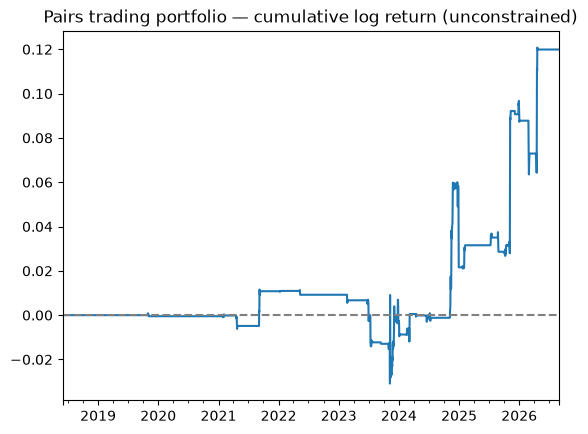

In [54]:
returns_df = pd.concat(portfolio_unweighted_returns, axis=1)

print(weights_df.columns.equals(returns_df.columns))
print(weights_df.index.equals(returns_df.index))

weighted_returns_df = weights_df * returns_df
portfolio_return = weighted_returns_df.sum(axis=1)

portfolio_return.cumsum().plot()
plt.axhline(0, color='gray', linestyle='--')
plt.title("Pairs trading portfolio — cumulative log return (unconstrained)")
plt.show()

True
True


C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\1980629273.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns_df = pd.concat(portfolio_unweighted_returns, axis=1)


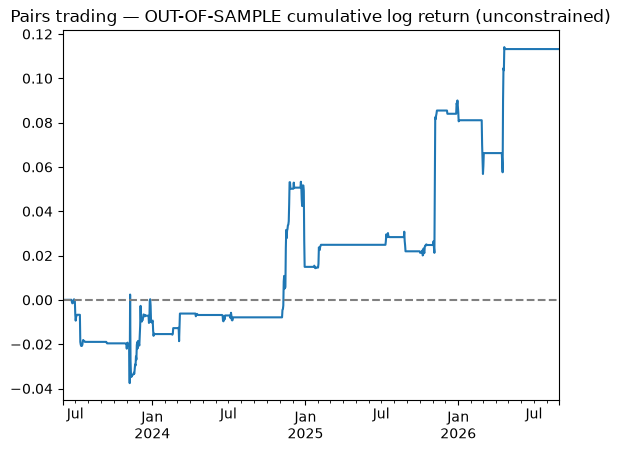

Final OOS cumulative log return: 0.113
2023-11-10   -0.029830
2024-12-29   -0.022445
2023-11-08   -0.017531
2023-07-13   -0.012273
2024-12-30   -0.011839
dtype: float64
2023-11-09    0.039984
2026-04-18    0.032575
2025-11-06    0.031891
2025-11-07    0.029298
2024-11-15    0.017455
dtype: float64


In [55]:
returns_df = pd.concat(portfolio_unweighted_returns, axis=1)

print(weights_df.columns.equals(returns_df.columns))
print(weights_df.index.equals(returns_df.index))

weighted_returns_df = weights_df * returns_df
portfolio_return = weighted_returns_df.sum(axis=1)

portfolio_return_oos = portfolio_return.loc[out_of_sample_start:]

portfolio_return_oos.cumsum().plot()
plt.axhline(0, color='gray', linestyle='--')
plt.title("Pairs trading — OUT-OF-SAMPLE cumulative log return (unconstrained)")
plt.show()

print(f"Final OOS cumulative log return: {portfolio_return_oos.cumsum().iloc[-1]:.3f}")
print(portfolio_return_oos.sort_values().head(5))
print(portfolio_return_oos.sort_values(ascending=False).head(5))

Final OOS cumulative log return (net of costs): 0.106


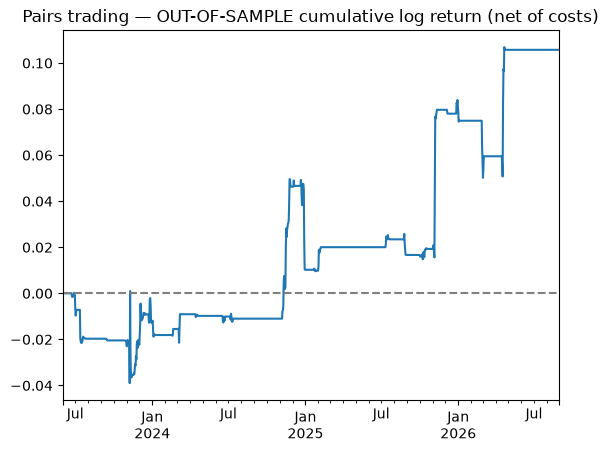

In [56]:
cost_rate = 0.0020

turnover = weights_df.diff().abs().sum(axis=1)
turnover.iloc[0] = weights_df.iloc[0].abs().sum()

daily_cost = turnover * cost_rate
portfolio_return_net = portfolio_return - daily_cost
portfolio_return_net_oos = portfolio_return_net.loc[out_of_sample_start:]

print(f"Final OOS cumulative log return (net of costs): {portfolio_return_net_oos.cumsum().iloc[-1]:.3f}")

portfolio_return_net_oos.cumsum().plot()
plt.axhline(0, color='gray', linestyle='--')
plt.title("Pairs trading — OUT-OF-SAMPLE cumulative log return (net of costs)")
plt.show()

In [57]:
returns = portfolio_return_net_oos.dropna()

periods_per_year = 365  # crypto trades every day, no market closures

# Sharpe ratio
mean_ret = returns.mean() * periods_per_year
vol = returns.std() * np.sqrt(periods_per_year)
sharpe_ratio = mean_ret / vol

# Annualized return and volatility
annualized_return = mean_ret
annualized_vol = vol

print(f"Sharpe Ratio: {sharpe_ratio:.3f}")
print(f"Annualized Return (log): {annualized_return:.3f}")
print(f"Annualized Volatility: {annualized_vol:.3f}")

Sharpe Ratio: 0.620
Annualized Return (log): 0.033
Annualized Volatility: 0.053


In [58]:
def compute_pair_return_v2(coin_A, coin_B, timeframe='24h', rolling_window=90, entry_z=2, exit_z=0.5, stop_loss_z=None):
    coin_A_data = np.log(data[coin_A].resample(timeframe).agg(ohlc_agg)['close'])
    coin_B_data = np.log(data[coin_B].resample(timeframe).agg(ohlc_agg)['close'])
    combined_coins_data = pd.concat([coin_A_data, coin_B_data], axis=1, keys=[coin_A, coin_B]).dropna()

    log_A = combined_coins_data[coin_A]
    log_B = combined_coins_data[coin_B]

    rolling_cov = log_A.rolling(window=rolling_window, min_periods=rolling_window).cov(log_B)
    rolling_var = log_B.rolling(window=rolling_window, min_periods=rolling_window).var()
    hedge_ratio = rolling_cov / rolling_var
    alpha = log_A.rolling(window=rolling_window, min_periods=rolling_window).mean() - hedge_ratio * log_B.rolling(window=rolling_window, min_periods=rolling_window).mean()

    spread = log_A - (hedge_ratio * log_B + alpha)
    rolling_mean = spread.shift(1).rolling(window=rolling_window).mean()
    rolling_std = spread.shift(1).rolling(window=rolling_window).std()
    z_scores = (spread - rolling_mean) / rolling_std

    position_entered = pd.Series(data=0, index=z_scores.index)
    previous_position = 0
    for date in z_scores.keys():
        z = z_scores[date]
        if stop_loss_z is not None and (previous_position != 0) and (abs(z) > stop_loss_z):
            position_entered[date] = 0
        elif (previous_position != 0) and (-exit_z < z < exit_z):
            position_entered[date] = 0
        elif (z > entry_z) or (previous_position == 1 and z > exit_z):
            position_entered[date] = 1
        elif (z < -entry_z) or (previous_position == -1 and z < -exit_z):
            position_entered[date] = -1
        else:
            position_entered[date] = 0
        previous_position = position_entered[date]

    coinA_returns = np.log(combined_coins_data[coin_A]/combined_coins_data.shift()[coin_A])
    coinB_returns = np.log(combined_coins_data[coin_B]/combined_coins_data.shift()[coin_B])
    current_pair_return = position_entered.shift(1) * (hedge_ratio.shift(1) * coinB_returns - coinA_returns)
    return position_entered, current_pair_return, hedge_ratio

In [59]:
def run_full_pipeline_full_history(entry_z, exit_z, stop_loss_z=None):
    pairs_position_entered_t = {}
    portfolio_unweighted_returns_t = {}
    for i in range(len(qualifying_pairs)):
        coin_A = qualifying_pairs.iloc[i]['coin_A']
        coin_B = qualifying_pairs.iloc[i]['coin_B']
        try:
            pos, ret = compute_pair_return(coin_A, coin_B, entry_z=entry_z, exit_z=exit_z, stop_loss_z=stop_loss_z)
            pairs_position_entered_t[(coin_A, coin_B)] = pos
            portfolio_unweighted_returns_t[(coin_A, coin_B)] = ret
        except Exception as e:
            continue

    positions_df_t = pd.concat(pairs_position_entered_t, axis=1).fillna(0)
    positions_shifted_t = positions_df_t.shift(1).fillna(0)

    weights_t = {}
    for date in positions_shifted_t.index:
        row_weights = pd.Series(0.0, index=positions_shifted_t.columns)
        for pair in elite_pairs_list:
            if pair in positions_shifted_t.columns and positions_shifted_t.loc[date, pair] != 0:
                row_weights[pair] = elite_weight_map[pair]
        for pair in regular_pairs_list:
            if pair in positions_shifted_t.columns and positions_shifted_t.loc[date, pair] != 0:
                row_weights[pair] = regular_weight
        weights_t[date] = row_weights
    weights_df_t = pd.DataFrame(weights_t).T

    returns_df_t = pd.concat(portfolio_unweighted_returns_t, axis=1)
    weighted_returns_df_t = weights_df_t * returns_df_t
    portfolio_return_t = weighted_returns_df_t.sum(axis=1)

    turnover_t = weights_df_t.diff().abs().sum(axis=1)
    turnover_t.iloc[0] = weights_df_t.iloc[0].abs().sum()
    daily_cost_t = turnover_t * cost_rate
    portfolio_return_net_t = portfolio_return_t - daily_cost_t

    return portfolio_return_net_t

In [60]:
final_entry_z, final_exit_z, final_stop_loss_z = 6, 2.5, 9

final_full_returns = run_full_pipeline_full_history(final_entry_z, final_exit_z, stop_loss_z=final_stop_loss_z)
final_oos_returns = final_full_returns.loc[out_of_sample_start:].dropna()

mean_ret = final_oos_returns.mean() * 365
vol = final_oos_returns.std() * np.sqrt(365)
final_oos_sharpe = mean_ret / vol

print(f"FINAL out-of-sample Sharpe: {final_oos_sharpe:.3f}")
print(f"FINAL out-of-sample cumulative log return: {final_oos_returns.cumsum().iloc[-1]:.3f}")

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\119960363.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_coins_data = pd.concat([coin_A_data, coin_B_data], axis=1, keys=[coin_A, coin_B]).dropna()
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\119960363.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling con

FINAL out-of-sample Sharpe: 0.622
FINAL out-of-sample cumulative log return: 0.106


C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\3602187338.py:29: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns_df_t = pd.concat(portfolio_unweighted_returns_t, axis=1)


In [61]:
def run_full_pipeline_v2(entry_z, exit_z, stop_loss_z=None):
    pairs_position, pairs_return, pairs_hedge = {}, {}, {}
    for i in range(len(qualifying_pairs)):
        coin_A = qualifying_pairs.iloc[i]['coin_A']
        coin_B = qualifying_pairs.iloc[i]['coin_B']
        try:
            pos, ret, hr = compute_pair_return_v2(coin_A, coin_B, entry_z=entry_z, exit_z=exit_z, stop_loss_z=stop_loss_z)
            pairs_position[(coin_A, coin_B)] = pos
            pairs_return[(coin_A, coin_B)] = ret
            pairs_hedge[(coin_A, coin_B)] = hr
        except Exception:
            continue

    positions_df = pd.concat(pairs_position, axis=1).fillna(0)
    hedge_df = pd.concat(pairs_hedge, axis=1)
    positions_shifted = positions_df.shift(1).fillna(0)
    hedge_shifted = hedge_df.shift(1)

    weights = {}
    for date in positions_shifted.index:
        row_weights = pd.Series(0.0, index=positions_shifted.columns)
        for pair in elite_pairs_list:
            if pair in positions_shifted.columns and positions_shifted.loc[date, pair] != 0:
                row_weights[pair] = elite_weight_map[pair]
        for pair in regular_pairs_list:
            if pair in positions_shifted.columns and positions_shifted.loc[date, pair] != 0:
                row_weights[pair] = regular_weight
        weights[date] = row_weights
    weights_df = pd.DataFrame(weights).T

    # dollar notional in each leg, per pair, per day
    notional_A = -positions_shifted * weights_df
    notional_B = positions_shifted * hedge_shifted * weights_df

    turnover = notional_A.diff().abs().sum(axis=1) + notional_B.diff().abs().sum(axis=1)
    turnover.iloc[0] = notional_A.iloc[0].abs().sum() + notional_B.iloc[0].abs().sum()

    returns_df = pd.concat(pairs_return, axis=1)
    weighted_returns_df = weights_df * returns_df
    portfolio_return = weighted_returns_df.sum(axis=1)

    daily_cost = turnover * cost_rate
    portfolio_return_net = portfolio_return - daily_cost

    return portfolio_return_net, turnover

In [62]:
final_returns_v2, turnover_v2 = run_full_pipeline_v2(6, 2.5, stop_loss_z=9)
final_oos_v2 = final_returns_v2.loc[out_of_sample_start:].dropna()

sharpe_v2 = (final_oos_v2.mean()*365) / (final_oos_v2.std()*np.sqrt(365))
print(f"Sharpe with proper leg-level turnover costs: {sharpe_v2:.3f}")
print(f"Average daily turnover (new method): {turnover_v2.loc[out_of_sample_start:].mean():.4f}")

C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\794932255.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_coins_data = pd.concat([coin_A_data, coin_B_data], axis=1, keys=[coin_A, coin_B]).dropna()
c:\Users\Kavya\Documents\WallStreetQuants\Python\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\794932255.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling con

Sharpe with proper leg-level turnover costs: 0.576
Average daily turnover (new method): 0.0065


C:\Users\Kavya\AppData\Local\Temp\ipykernel_8008\1946861918.py:38: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns_df = pd.concat(pairs_return, axis=1)


In [63]:
print(f"Old (pair-level) avg turnover: {turnover.loc[out_of_sample_start:].mean():.4f}")
print(f"New (leg-level, hedge-aware) avg turnover: {turnover_v2.loc[out_of_sample_start:].mean():.4f}")

Old (pair-level) avg turnover: 0.0032
New (leg-level, hedge-aware) avg turnover: 0.0065


In [64]:
btc_price = data['BTCUSDT'].resample('24h').agg(ohlc_agg)['close']
btc_returns = np.log(btc_price / btc_price.shift())
btc_returns_oos = btc_returns.loc[out_of_sample_start:].reindex(final_oos_returns.index).dropna()
strategy_returns_aligned = final_oos_v2.reindex(btc_returns_oos.index)

btc_mean = btc_returns_oos.mean() * 365
btc_vol = btc_returns_oos.std() * np.sqrt(365)
btc_sharpe = btc_mean / btc_vol

correlation_with_btc = strategy_returns_aligned.corr(btc_returns_oos)

print(f"BTC buy-and-hold OOS Sharpe: {btc_sharpe:.3f}")
print(f"Correlation with BTC: {correlation_with_btc:.3f}")

BTC buy-and-hold OOS Sharpe: 0.702
Correlation with BTC: 0.014


In [65]:
print("\nBlended portfolio Sharpe by BTC weight:")
for btc_weight in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    strat_weight = 1 - btc_weight
    blended = btc_weight * btc_returns_oos + strat_weight * strategy_returns_aligned
    blended_sharpe = (blended.mean() * 365) / (blended.std() * np.sqrt(365))
    print(f"  BTC {btc_weight:.1f} / Strategy {strat_weight:.1f}: Sharpe = {blended_sharpe:.3f}")


Blended portfolio Sharpe by BTC weight:
  BTC 0.0 / Strategy 1.0: Sharpe = 0.576
  BTC 0.1 / Strategy 0.9: Sharpe = 0.896
  BTC 0.2 / Strategy 0.8: Sharpe = 0.873
  BTC 0.3 / Strategy 0.7: Sharpe = 0.823
  BTC 0.5 / Strategy 0.5: Sharpe = 0.761
  BTC 0.7 / Strategy 0.3: Sharpe = 0.728
  BTC 1.0 / Strategy 0.0: Sharpe = 0.702


In [66]:
X = sm.add_constant(btc_returns_oos)
reg_results = sm.OLS(strategy_returns_aligned, X).fit()

daily_alpha = reg_results.params['const']
beta = reg_results.params[btc_returns_oos.name] if btc_returns_oos.name in reg_results.params.index else reg_results.params.iloc[1]
alpha_tstat = reg_results.tvalues['const']

annualized_alpha = daily_alpha * 365

wealth = np.exp(final_oos_returns.cumsum())
running_max = wealth.cummax()
drawdown = (wealth - running_max) / running_max
max_drawdown = drawdown.min()

mean_ret = final_oos_returns.mean() * 365
vol = final_oos_returns.std() * np.sqrt(365)
sharpe = mean_ret / vol

results_table = pd.DataFrame({
    'Metric': [
        'OOS Sharpe Ratio',
        'Annualized Return',
        'Annualized Volatility',
        'Correlation with BTC',
        'Annualized Alpha (vs BTC)',
        'Beta (vs BTC)',
        'Alpha t-stat',
        'Max Drawdown'
    ],
    'Value': [
        f"{sharpe:.3f}",
        f"{mean_ret:.3f}",
        f"{vol:.3f}",
        f"{correlation_with_btc:.3f}",
        f"{annualized_alpha:.3f}",
        f"{beta:.3f}",
        f"{alpha_tstat:.3f}",
        f"{max_drawdown:.2%}"
    ]
})

print(results_table.to_string(index=False))

                   Metric  Value
         OOS Sharpe Ratio  0.622
        Annualized Return  0.033
    Annualized Volatility  0.053
     Correlation with BTC  0.014
Annualized Alpha (vs BTC)  0.030
            Beta (vs BTC)  0.002
             Alpha t-stat  1.020
             Max Drawdown -3.92%
